# Systematic Comparison: Importance Sampling for Neural Posterior Estimation

## Mathematical Framework

We train GRU-based neural posterior estimators on AR(1) time series $x_t = \rho\, x_{t-1} + \sigma\, \varepsilon_t$ with parameters $\theta = (\rho, \sigma)$.

**Importance-weighted loss.** For proposal $q_\alpha(\theta)$ built from Beta distributions parameterised by $\alpha$:

$$\mathcal{L}_\alpha = \frac{1}{N}\sum_{i=1}^{N} w(\theta_i)\,\bigl\|\hat\theta(x_i) - \theta_i\bigr\|^2, \qquad w(\theta) = \frac{p(\theta)}{q_\alpha(\theta)}$$

where $p(\theta) = \text{Uniform}(\rho \in [-1,1],\; \sigma \in [0,A])$ is the target prior.

**Effective Sample Size:**

$$\text{ESS} = \frac{1}{\sum_{i=1}^N \bar{w}_i^2}, \qquad \bar{w}_i = \frac{w_i}{\sum_j w_j}$$

**Bias-Variance Decomposition** (across $R$ independent runs):

$$\text{MSE}_i = \underbrace{(\bar{\hat\theta}_i - \theta_i)^2}_{\text{Bias}^2} + \underbrace{\frac{1}{R}\sum_{r=1}^{R} (\hat\theta_i^{(r)} - \bar{\hat\theta}_i)^2}_{\text{Variance}}$$

## Experimental Protocol

| Parameter | Value |
|-----------|-------|
| Independent runs per $\alpha$ | $R = 5$ |
| Alpha values | $\{1.0,\; 0.5,\; 0.3,\; 0.1\}$ |
| Total models trained | 20 |
| Shared test set | $N = 10{,}000$ (uniform, fixed seed) |
| Training | 128 epochs, 128 batches/epoch, batch\_size = 128 |
| Architecture | Improved GRU (mean pooling + $\exp(\log\sigma)$, mlp\_hidden = 128) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_rel, wilcoxon
import torch
import torch.nn as nn
from tqdm import tqdm
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [ ]:
# Configuration
A = 5.0
T = 64

ALPHA_VALUES = [1.0, 0.5, 0.3, 0.1]

N_EPOCHS = 128
N_BATCHES_PER_EPOCH = 128
TRAINING_BATCH_SIZE = 128

N_EVAL = 1_000  # shared test set size
R = 5            # independent runs per alpha
BASE_SEED = 42
BETA_SIGMA = 1   # Beta(alpha, 1) for sigma proposal

print("Configuration loaded")

Configuration loaded


In [3]:
# ── Reproducibility ──────────────────────────────────────────────────
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ── Proposal sampling & IS weights ──────────────────────────────────
def sample_from_proposal(batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device='cpu'):
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, beta_sigma, size=batch_size)
    rho = 2 * rho_tilde - 1
    sigma = A * sigma_tilde
    rho = torch.tensor(rho, dtype=torch.float32, device=device)
    sigma = torch.tensor(sigma, dtype=torch.float32, device=device)
    return rho, sigma

def compute_importance_weights(rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A):
    if torch.is_tensor(rho):
        rho = rho.cpu().numpy()
        sigma = sigma.cpu().numpy()
    rho_tilde = (rho + 1) / 2
    sigma_tilde = sigma / A
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho) / 2
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, beta_sigma) / A
    q_theta = q_rho * q_sigma
    p_theta = 1.0 / (2 * A)
    return p_theta / q_theta

# ── AR(1) simulator ─────────────────────────────────────────────────
def simulate_ar1_batch(rho, sigma, T, batch_size, device='cpu'):
    eps = torch.randn(batch_size, T, device=device) * sigma[:, None]
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    x0 = torch.randn(batch_size, device=device) * sigma / torch.sqrt(1 - rho_safe**2 + 1e-8)
    x = torch.zeros(batch_size, T, device=device)
    x[:, 0] = rho * x0 + eps[:, 0]
    for t in range(1, T):
        x[:, t] = rho * x[:, t-1] + eps[:, t]
    return x

# ── Gibbs sampler ───────────────────────────────────────────────────
def truncated_normal(mu, sigma, a=-1, b=1):
    while True:
        s = np.random.normal(mu, sigma)
        if a <= s <= b:
            return s

def truncated_gamma(shape, scale, a=1/A**2):
    while True:
        s = np.random.gamma(shape, scale)
        if s >= a:
            return s

def gibbs(x, n_iter=1000):
    T_len = len(x) - 1
    Q = np.sum(x[:-1]**2)
    rho_hat = np.sum(x[:-1] * x[1:]) / Q
    const = np.sum(x[1:]**2) - Q * rho_hat**2
    S = lambda rho: Q * (rho - rho_hat)**2 + const
    samples = np.zeros((n_iter, 2))
    for i in range(n_iter):
        lambda_ = truncated_gamma(T_len/2, 2/(S(rho_hat) + 1e-6))
        sig = 1/np.sqrt(lambda_)
        samples[i, 1] = sig
        samples[i, 0] = truncated_normal(rho_hat, sig/np.sqrt(Q))
    return samples

# ── Model ───────────────────────────────────────────────────────────
class GRUPosteriorEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 32), nn.ReLU(),
            nn.Linear(32, 2))

    def forward(self, x):
        x = x.unsqueeze(-1)
        gru_out, _ = self.gru(x)
        pooled = gru_out.mean(dim=1)
        raw = self.mlp(pooled)
        rho = torch.tanh(raw[:, 0])
        sigma = torch.exp(raw[:, 1])
        return torch.stack([rho, sigma], dim=1)

print("All core functions loaded")

All core functions loaded


## B. Proposal Distribution Analysis

alpha=1.0: ESS = 5000/5000 = 1.000
alpha=0.5: ESS = 3018/5000 = 0.604
alpha=0.3: ESS = 1550/5000 = 0.310
alpha=0.1: ESS = 254/5000 = 0.051


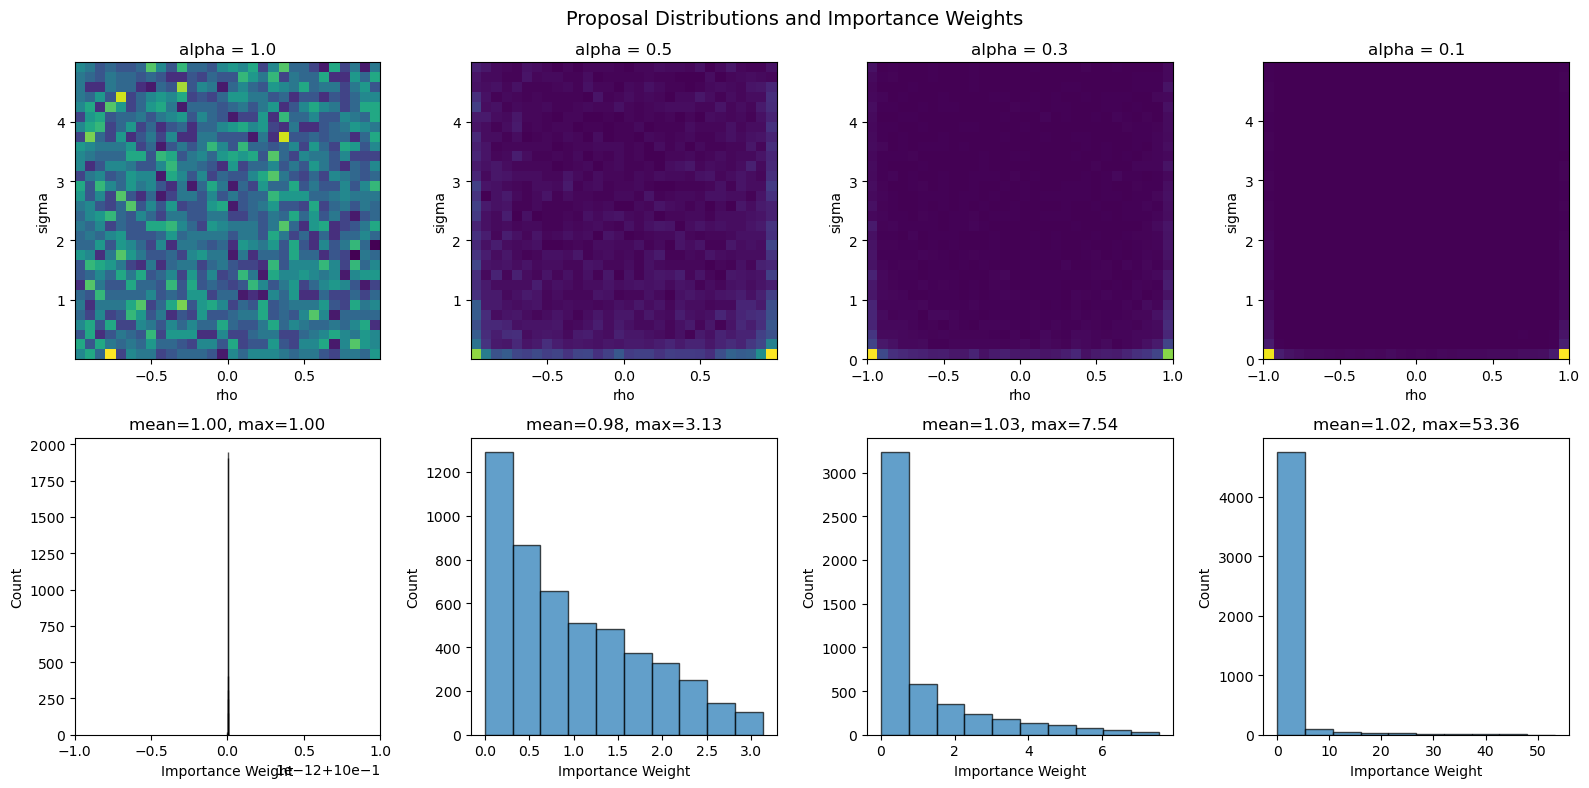

In [5]:
# Visualise proposals and compute ESS
set_seed(0)
fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(16, 8))

for i, alpha in enumerate(ALPHA_VALUES):
    n = 5000
    rho, sigma = sample_from_proposal(n, alpha, alpha, BETA_SIGMA, A, device='cpu')
    rho_np = rho.numpy()
    sigma_np = sigma.numpy()
    weights = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)

    axes[0, i].hist2d(rho_np, sigma_np, bins=30, cmap='viridis')
    axes[0, i].set_xlabel('rho'); axes[0, i].set_ylabel('sigma')
    axes[0, i].set_title(f'alpha = {alpha}')

    axes[1, i].hist(weights, bins=10, alpha=0.7, edgecolor='black')
    axes[1, i].set_xlabel('Importance Weight'); axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'mean={weights.mean():.2f}, max={weights.max():.2f}')

    # ESS
    w_norm = weights / weights.sum()
    ess = 1.0 / np.sum(w_norm**2)
    print(f"alpha={alpha}: ESS = {ess:.0f}/{n} = {ess/n:.3f}")

plt.suptitle('Proposal Distributions and Importance Weights', fontsize=14)
plt.tight_layout()
plt.show()

## C. Shared Test Set & Gibbs Baseline

In [6]:
# Generate shared uniform test set (fixed seed, separate from training)
set_seed(0)
rho_eval = torch.empty(N_EVAL, device='cpu').uniform_(-1, 1)
sigma_eval = torch.empty(N_EVAL, device='cpu').uniform_(0, A)
x_eval = simulate_ar1_batch(rho_eval, sigma_eval, T, N_EVAL, device='cpu')

rho_eval_np = rho_eval.numpy()
sigma_eval_np = sigma_eval.numpy()
x_eval_np = x_eval.numpy()

print(f"Shared test set: {N_EVAL} samples generated (seed=0)")

Shared test set: 10000 samples generated (seed=0)


In [7]:
# Gibbs sampler baseline
print("Running Gibbs sampler on shared test set...")
set_seed(1)

rho_gibbs = np.zeros(N_EVAL)
sigma_gibbs = np.zeros(N_EVAL)

for i in tqdm(range(N_EVAL)):
    samples = gibbs(x_eval_np[i], n_iter=1000)
    rho_gibbs[i] = np.mean(samples[:, 0])
    sigma_gibbs[i] = np.mean(samples[:, 1])

mse_rho_gibbs = np.mean((rho_eval_np - rho_gibbs)**2)
mse_sigma_gibbs = np.mean((sigma_eval_np - sigma_gibbs)**2)
total_gibbs = mse_rho_gibbs + mse_sigma_gibbs

print(f"Gibbs MSE: rho={mse_rho_gibbs:.6f}, sigma={mse_sigma_gibbs:.6f}, total={total_gibbs:.6f}")

Running Gibbs sampler on shared test set...


100%|██████████| 10000/10000 [01:23<00:00, 119.29it/s]

Gibbs MSE: rho=0.010922, sigma=0.053989, total=0.064911


## D. Multi-Run Training (4 alphas x 5 runs = 20 models)

In [8]:
def train_model(alpha_rho, alpha_sigma, beta_sigma, n_epochs, n_batches,
                batch_size, device, seed=None):
    """Train one GRU model. Returns (model, train_losses, test_losses, ess_history)."""
    if seed is not None:
        set_seed(seed)

    model = GRUPosteriorEstimator(
        input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

    train_losses, test_losses, ess_history = [], [], []

    # Internal validation set (fixed seed 99999, restored after)
    np_state = np.random.get_state()
    torch_state = torch.random.get_rng_state()
    cuda_state = torch.cuda.get_rng_state() if torch.cuda.is_available() else None
    set_seed(99999)
    rho_test = torch.empty(1024, device=device).uniform_(-1, 1)
    sigma_test = torch.empty(1024, device=device).uniform_(0, A)
    x_test = simulate_ar1_batch(rho_test, sigma_test, T, 1024, device=device)
    np.random.set_state(np_state)
    torch.random.set_rng_state(torch_state)
    if cuda_state is not None:
        torch.cuda.set_rng_state(cuda_state)

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_ess = 0.0

        for _ in range(n_batches):
            rho, sigma = sample_from_proposal(
                batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device=device)

            weights = compute_importance_weights(
                rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A)
            weights = torch.tensor(weights, dtype=torch.float32, device=device)
            weights = torch.nan_to_num(weights, nan=1.0, posinf=10.0, neginf=0.1)
            weights = torch.clamp(weights, min=0.1, max=10.0)
            w_norm = weights / weights.sum()

            epoch_ess += 1.0 / (w_norm**2).sum().item()

            x = simulate_ar1_batch(rho, sigma, T, batch_size, device=device)
            if torch.isnan(x).any() or torch.isinf(x).any():
                continue

            theta_pred = model(x)
            if torch.isnan(theta_pred).any() or torch.isinf(theta_pred).any():
                continue

            loss_per_sample = ((theta_pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)
            loss = torch.sum(w_norm * loss_per_sample)

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        train_losses.append(epoch_loss / n_batches)
        ess_history.append(epoch_ess / n_batches)

        model.eval()
        with torch.no_grad():
            pred_test = model(x_test)
            tl = ((pred_test - torch.stack([rho_test, sigma_test], dim=1))**2).mean().item()
            test_losses.append(tl)

    return model, train_losses, test_losses, ess_history

print("train_model() defined")

train_model() defined


In [ ]:
# Main training loop: 4 alphas x 5 runs
all_models = {}
all_train_losses = {}
all_test_losses = {}
all_ess_histories = {}
training_times = {}

for ai, alpha in enumerate(ALPHA_VALUES):
    all_models[alpha] = {}
    all_train_losses[alpha] = {}
    all_test_losses[alpha] = {}
    all_ess_histories[alpha] = {}
    training_times[alpha] = {}

    print(f"\n{'='*80}")
    print(f"ALPHA = {alpha}  ({R} runs)")
    print(f"{'='*80}")

    for run in range(R):
        seed = BASE_SEED + ai * 100 + run
        print(f"  Run {run+1}/{R} (seed={seed})... ", end="", flush=True)

        t0 = time.time()
        model, trl, tel, essh = train_model(
            alpha_rho=alpha, alpha_sigma=alpha, beta_sigma=BETA_SIGMA,
            n_epochs=N_EPOCHS, n_batches=N_BATCHES_PER_EPOCH,
            batch_size=TRAINING_BATCH_SIZE, device=device, seed=seed)
        elapsed = time.time() - t0

        all_models[alpha][run] = model
        all_train_losses[alpha][run] = trl
        all_test_losses[alpha][run] = tel
        all_ess_histories[alpha][run] = essh
        training_times[alpha][run] = elapsed

        print(f"done in {elapsed:.1f}s  (final test loss: {tel[-1]:.4f})")

total_time = sum(t for a in training_times for t in training_times[a].values())
print(f"\n{'='*80}")
print(f"All {len(ALPHA_VALUES) * R} models trained in {total_time/60:.1f} minutes")
print(f"{'='*80}")


ALPHA = 1.0  (5 runs)
  Run 1/5 (seed=42)... 

In [ ]:
# Collect predictions on shared test set
all_predictions = {}  # all_predictions[alpha][run] = (N, 2)
x_eval_gpu = x_eval.to(device)

for alpha in ALPHA_VALUES:
    all_predictions[alpha] = {}
    for run in range(R):
        all_models[alpha][run].eval()
        with torch.no_grad():
            pred = all_models[alpha][run](x_eval_gpu).cpu().numpy()
            all_predictions[alpha][run] = pred

# Mean prediction across runs
mean_preds = {}
for alpha in ALPHA_VALUES:
    stacked = np.stack([all_predictions[alpha][r] for r in range(R)], axis=0)
    mean_preds[alpha] = stacked.mean(axis=0)

print(f"Predictions collected: {len(ALPHA_VALUES)} alphas x {R} runs on {N_EVAL} test points")

## E. Training Convergence

In [ ]:
# Confidence band plots: training & test loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(ALPHA_VALUES)))
epochs = np.arange(N_EPOCHS)

for i, alpha in enumerate(ALPHA_VALUES):
    # Training loss
    train_arr = np.array([all_train_losses[alpha][r] for r in range(R)])
    mu, sd = train_arr.mean(axis=0), train_arr.std(axis=0)
    axes[0].plot(epochs, mu, color=colors[i], label=f'alpha={alpha}')
    axes[0].fill_between(epochs, mu - sd, mu + sd, color=colors[i], alpha=0.15)

    # Test loss
    test_arr = np.array([all_test_losses[alpha][r] for r in range(R)])
    mu, sd = test_arr.mean(axis=0), test_arr.std(axis=0)
    axes[1].plot(epochs, mu, color=colors[i], label=f'alpha={alpha}')
    axes[1].fill_between(epochs, mu - sd, mu + sd, color=colors[i], alpha=0.15)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted Loss')
axes[0].set_title('Training Loss (mean +/- std)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
axes[1].set_title('Test Loss (mean +/- std)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ESS over training + per-run loss table
fig, ax = plt.subplots(figsize=(10, 5))
for i, alpha in enumerate(ALPHA_VALUES):
    ess_arr = np.array([all_ess_histories[alpha][r] for r in range(R)])
    mu, sd = ess_arr.mean(axis=0), ess_arr.std(axis=0)
    ax.plot(epochs, mu, color=colors[i], label=f'alpha={alpha}')
    ax.fill_between(epochs, mu - sd, mu + sd, color=colors[i], alpha=0.15)

ax.axhline(y=TRAINING_BATCH_SIZE, color='k', linestyle=':', label=f'Batch size ({TRAINING_BATCH_SIZE})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Effective Sample Size')
ax.set_title('ESS During Training (mean +/- std across runs)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Per-run final test loss table
print("\n" + "="*80)
print("FINAL TEST LOSS PER RUN")
print("="*80)
header = f"{'Alpha':<10}" + "".join(f"{'Run '+str(r+1):<12}" for r in range(R)) + f"{'Mean':<12}{'Std':<12}"
print(header)
print("-"*80)
for alpha in ALPHA_VALUES:
    losses = [all_test_losses[alpha][r][-1] for r in range(R)]
    row = f"{'a='+str(alpha):<10}" + "".join(f"{l:<12.4f}" for l in losses)
    row += f"{np.mean(losses):<12.4f}{np.std(losses):<12.4f}"
    print(row)
print("="*80)

## F. Aggregate Performance

In [ ]:
# Comprehensive metrics table
print("\n" + "="*110)
print(f"AGGREGATE PERFORMANCE (mean +/- std across R={R} runs)")
print("="*110)
print(f"{'Alpha':<10} {'MSE(rho)':<20} {'MSE(sigma)':<20} {'MAE(rho)':<20} {'MAE(sigma)':<20} {'Total MSE':<20}")
print("-"*110)

mae_rho_gibbs = np.mean(np.abs(rho_eval_np - rho_gibbs))
mae_sigma_gibbs = np.mean(np.abs(sigma_eval_np - sigma_gibbs))
print(f"{'Gibbs':<10} {mse_rho_gibbs:<20.6f} {mse_sigma_gibbs:<20.6f} "
      f"{mae_rho_gibbs:<20.6f} {mae_sigma_gibbs:<20.6f} {total_gibbs:<20.6f}")

run_metrics = {}
for alpha in ALPHA_VALUES:
    mse_rho_runs, mse_sigma_runs, mae_rho_runs, mae_sigma_runs, total_runs = [], [], [], [], []
    for r in range(R):
        pred = all_predictions[alpha][r]
        mr = np.mean((rho_eval_np - pred[:, 0])**2)
        ms = np.mean((sigma_eval_np - pred[:, 1])**2)
        ar = np.mean(np.abs(rho_eval_np - pred[:, 0]))
        asig = np.mean(np.abs(sigma_eval_np - pred[:, 1]))
        mse_rho_runs.append(mr); mse_sigma_runs.append(ms)
        mae_rho_runs.append(ar); mae_sigma_runs.append(asig)
        total_runs.append(mr + ms)

    run_metrics[alpha] = dict(mse_rho=mse_rho_runs, mse_sigma=mse_sigma_runs,
                              mae_rho=mae_rho_runs, mae_sigma=mae_sigma_runs, total=total_runs)
    fmt = lambda v: f"{np.mean(v):.4f}+/-{np.std(v):.4f}"
    print(f"{'a='+str(alpha):<10} {fmt(mse_rho_runs):<20} {fmt(mse_sigma_runs):<20} "
          f"{fmt(mae_rho_runs):<20} {fmt(mae_sigma_runs):<20} {fmt(total_runs):<20}")
print("="*110)

In [ ]:
# Box plots of per-run total MSE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
alphas_str = [f'a={a}' for a in ALPHA_VALUES]

for col, (key, title) in enumerate([('total', 'Total MSE'),
                                     ('mse_rho', 'MSE(rho)'),
                                     ('mse_sigma', 'MSE(sigma)')]):
    data = [run_metrics[a][key] for a in ALPHA_VALUES]
    bp = axes[col].boxplot(data, labels=alphas_str, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.5)
    for i, alpha in enumerate(ALPHA_VALUES):
        axes[col].scatter([i+1]*R, run_metrics[alpha][key], color=colors[i], zorder=5, s=40)

    gibbs_ref = {'total': total_gibbs, 'mse_rho': mse_rho_gibbs, 'mse_sigma': mse_sigma_gibbs}[key]
    axes[col].axhline(y=gibbs_ref, color='r', linestyle='--', label='Gibbs')
    axes[col].set_ylabel(title); axes[col].set_title(title + ' per Run')
    axes[col].legend(); axes[col].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:
# Statistical tests: paired t-test on per-sample errors
print("\n" + "="*80)
print("STATISTICAL TESTS: paired t-test on per-sample squared errors (N={})".format(N_EVAL))
print("Using mean-across-runs predictions for each alpha")
print("="*80)

errors_baseline = (mean_preds[1.0][:, 0] - rho_eval_np)**2 + \
                  (mean_preds[1.0][:, 1] - sigma_eval_np)**2

for alpha in [0.5, 0.3, 0.1]:
    errors_alpha = (mean_preds[alpha][:, 0] - rho_eval_np)**2 + \
                   (mean_preds[alpha][:, 1] - sigma_eval_np)**2

    t_stat, p_val = ttest_rel(errors_baseline, errors_alpha)
    mean_diff = np.mean(errors_baseline - errors_alpha)

    print(f"\nalpha=1.0 vs alpha={alpha}:")
    print(f"  Mean MSE difference (baseline - IS): {mean_diff:+.6f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.6e}")
    if p_val < 0.05:
        winner = "alpha=1.0 (uniform)" if mean_diff < 0 else f"alpha={alpha} (IS)"
        print(f"  Significant at 5%: {winner} is better")
    else:
        print(f"  Not significant at 5%")

    # Wilcoxon as robustness check
    try:
        w_stat, w_p = wilcoxon(errors_baseline, errors_alpha)
        print(f"  Wilcoxon signed-rank: W={w_stat:.1f}, p={w_p:.6e}")
    except Exception:
        pass

print("="*80)

## G. Bias-Variance Decomposition

$$\text{MSE}_i = \underbrace{(\bar{\hat\theta}_i - \theta_i)^2}_{\text{Bias}^2} + \underbrace{\frac{1}{R}\sum_{r=1}^{R} (\hat\theta_i^{(r)} - \bar{\hat\theta}_i)^2}_{\text{Variance}}$$

In [ ]:
# Compute bias-variance decomposition
print("\n" + "="*110)
print("BIAS-VARIANCE DECOMPOSITION")
print("="*110)

bv_results = {}
true_vals = np.stack([rho_eval_np, sigma_eval_np], axis=1)  # (N, 2)

for alpha in ALPHA_VALUES:
    preds = np.stack([all_predictions[alpha][r] for r in range(R)], axis=0)  # (R, N, 2)
    mean_pred = preds.mean(axis=0)  # (N, 2)

    bias_sq = (mean_pred - true_vals)**2                             # (N, 2)
    variance = np.mean((preds - mean_pred[None, :, :])**2, axis=0)  # (N, 2)
    mse_decomp = bias_sq + variance                                  # (N, 2)

    bv_results[alpha] = dict(
        bias_sq_rho=bias_sq[:, 0].mean(), bias_sq_sigma=bias_sq[:, 1].mean(),
        var_rho=variance[:, 0].mean(),     var_sigma=variance[:, 1].mean(),
        mse_rho=mse_decomp[:, 0].mean(),   mse_sigma=mse_decomp[:, 1].mean(),
        bias_sq=bias_sq, variance=variance, mse=mse_decomp)

print(f"{'Alpha':<8} {'Bias2(rho)':<14} {'Var(rho)':<14} {'MSE(rho)':<14} "
      f"{'Bias2(sig)':<14} {'Var(sig)':<14} {'MSE(sig)':<14} {'Total MSE':<14}")
print("-"*110)
for alpha in ALPHA_VALUES:
    bv = bv_results[alpha]
    total = bv['mse_rho'] + bv['mse_sigma']
    print(f"{'a='+str(alpha):<8} {bv['bias_sq_rho']:<14.6f} {bv['var_rho']:<14.6f} {bv['mse_rho']:<14.6f} "
          f"{bv['bias_sq_sigma']:<14.6f} {bv['var_sigma']:<14.6f} {bv['mse_sigma']:<14.6f} {total:<14.6f}")

print("\nVerification (Bias^2 + Var = MSE):")
for alpha in ALPHA_VALUES:
    bv = bv_results[alpha]
    err_r = abs(bv['bias_sq_rho'] + bv['var_rho'] - bv['mse_rho'])
    err_s = abs(bv['bias_sq_sigma'] + bv['var_sigma'] - bv['mse_sigma'])
    ok = "PASS" if max(err_r, err_s) < 1e-10 else "FAIL"
    print(f"  a={alpha}: rho residual={err_r:.2e}, sigma residual={err_s:.2e}  [{ok}]")
print("="*110)

In [ ]:
# Stacked bar chart: Bias^2 vs Variance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x_pos = np.arange(len(ALPHA_VALUES))
width = 0.6

for col, param in enumerate(['rho', 'sigma']):
    b2 = [bv_results[a][f'bias_sq_{param}'] for a in ALPHA_VALUES]
    va = [bv_results[a][f'var_{param}'] for a in ALPHA_VALUES]
    axes[col].bar(x_pos, b2, width, label='Bias^2', color='steelblue')
    axes[col].bar(x_pos, va, width, bottom=b2, label='Variance', color='coral')
    axes[col].set_xticks(x_pos)
    axes[col].set_xticklabels([f'a={a}' for a in ALPHA_VALUES])
    axes[col].set_ylabel('MSE'); axes[col].set_title(f'Bias^2-Variance: {param}')
    axes[col].legend(); axes[col].grid(True, alpha=0.3, axis='y')

plt.suptitle('Bias^2-Variance Decomposition', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Spatial heatmaps: Bias^2, Variance, MSE over (rho, sigma) space
N_BINS = 20
rho_edges = np.linspace(-1, 1, N_BINS + 1)
sigma_edges = np.linspace(0, A, N_BINS + 1)
rho_bin_idx = np.clip(np.digitize(rho_eval_np, rho_edges) - 1, 0, N_BINS - 1)
sigma_bin_idx = np.clip(np.digitize(sigma_eval_np, sigma_edges) - 1, 0, N_BINS - 1)

fig, axes = plt.subplots(len(ALPHA_VALUES), 3, figsize=(18, 5 * len(ALPHA_VALUES)))

for ai, alpha in enumerate(ALPHA_VALUES):
    bv = bv_results[alpha]
    for j, (metric, name) in enumerate([(bv['bias_sq'], 'Bias^2'),
                                         (bv['variance'], 'Variance'),
                                         (bv['mse'], 'MSE')]):
        total_metric = metric[:, 0] + metric[:, 1]
        grid = np.full((N_BINS, N_BINS), np.nan)
        for ri in range(N_BINS):
            for si in range(N_BINS):
                mask = (rho_bin_idx == ri) & (sigma_bin_idx == si)
                if mask.sum() > 0:
                    grid[si, ri] = np.mean(total_metric[mask])

        im = axes[ai, j].imshow(grid, origin='lower', aspect='auto',
                                extent=[-1, 1, 0, A], cmap='viridis')
        plt.colorbar(im, ax=axes[ai, j])
        axes[ai, j].set_xlabel('rho'); axes[ai, j].set_ylabel('sigma')
        axes[ai, j].set_title(f'a={alpha}: {name}')

plt.suptitle('Spatial Bias^2-Variance-MSE Heatmaps (20x20 grid)', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Difference heatmaps: MSE[alpha] - MSE[1.0]
baseline_total = bv_results[1.0]['mse'][:, 0] + bv_results[1.0]['mse'][:, 1]
baseline_grid = np.full((N_BINS, N_BINS), np.nan)
for ri in range(N_BINS):
    for si in range(N_BINS):
        mask = (rho_bin_idx == ri) & (sigma_bin_idx == si)
        if mask.sum() > 0:
            baseline_grid[si, ri] = np.mean(baseline_total[mask])

is_alphas = [a for a in ALPHA_VALUES if a != 1.0]
fig, axes = plt.subplots(1, len(is_alphas), figsize=(6 * len(is_alphas), 5))
if len(is_alphas) == 1:
    axes = [axes]

for i, alpha in enumerate(is_alphas):
    alpha_total = bv_results[alpha]['mse'][:, 0] + bv_results[alpha]['mse'][:, 1]
    alpha_grid = np.full((N_BINS, N_BINS), np.nan)
    for ri in range(N_BINS):
        for si in range(N_BINS):
            mask = (rho_bin_idx == ri) & (sigma_bin_idx == si)
            if mask.sum() > 0:
                alpha_grid[si, ri] = np.mean(alpha_total[mask])

    diff_grid = alpha_grid - baseline_grid
    vmax = np.nanmax(np.abs(diff_grid))
    im = axes[i].imshow(diff_grid, origin='lower', aspect='auto',
                        extent=[-1, 1, 0, A], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=axes[i])
    axes[i].set_xlabel('rho'); axes[i].set_ylabel('sigma')
    axes[i].set_title(f'MSE(a={alpha}) - MSE(a=1.0)\nBlue=IS better, Red=IS worse')

plt.suptitle('Difference Heatmaps: IS vs Uniform Baseline', fontsize=14)
plt.tight_layout(); plt.show()

## H. Regional / Boundary Performance

| Region | Definition |
|--------|-----------|
| Interior | $|\rho| < 0.8$ and $0.5 < \sigma < 4$ |
| High $|\rho|$ | $|\rho| > 0.95$ |
| Low $\sigma$ | $\sigma < 0.2$ |
| High $\sigma$ | $\sigma > 4.0$ |

In [ ]:
# Regional MSE table
regions = {
    'Interior': (np.abs(rho_eval_np) < 0.8) & (sigma_eval_np > 0.5) & (sigma_eval_np < 4.0),
    'High |rho| (>0.95)': np.abs(rho_eval_np) > 0.95,
    'Low sigma (<0.2)': sigma_eval_np < 0.2,
    'High sigma (>4.0)': sigma_eval_np > 4.0,
}

print("\n" + "="*80)
print(f"REGIONAL MSE (mean +/- std across R={R} runs)")
print("="*80)

regional_metrics = {}

for region_name, mask in regions.items():
    n_samples = mask.sum()
    print(f"\n{region_name} ({n_samples} samples)")
    print(f"{'Alpha':<10} {'MSE(rho)':<22} {'MSE(sigma)':<22} {'Total MSE':<22}")
    print("-"*76)

    g_rho = np.mean((rho_eval_np[mask] - rho_gibbs[mask])**2)
    g_sig = np.mean((sigma_eval_np[mask] - sigma_gibbs[mask])**2)
    print(f"{'Gibbs':<10} {g_rho:<22.6f} {g_sig:<22.6f} {g_rho+g_sig:<22.6f}")

    regional_metrics[region_name] = {}
    for alpha in ALPHA_VALUES:
        rho_runs = [np.mean((rho_eval_np[mask] - all_predictions[alpha][r][mask, 0])**2) for r in range(R)]
        sig_runs = [np.mean((sigma_eval_np[mask] - all_predictions[alpha][r][mask, 1])**2) for r in range(R)]
        totals = [rr + sr for rr, sr in zip(rho_runs, sig_runs)]
        regional_metrics[region_name][alpha] = totals

        fmt = lambda v: f"{np.mean(v):.4f}+/-{np.std(v):.4f}"
        print(f"{'a='+str(alpha):<10} {fmt(rho_runs):<22} {fmt(sig_runs):<22} {fmt(totals):<22}")

print("="*80)

In [ ]:
# Regional box plots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for idx, (region_name, mask) in enumerate(regions.items()):
    ax = axes_flat[idx]
    data = [regional_metrics[region_name][a] for a in ALPHA_VALUES]
    bp = ax.boxplot(data, labels=[f'a={a}' for a in ALPHA_VALUES], patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.5)
    for i, alpha in enumerate(ALPHA_VALUES):
        ax.scatter([i+1]*R, regional_metrics[region_name][alpha], color=colors[i], zorder=5, s=40)

    g_rho = np.mean((rho_eval_np[mask] - rho_gibbs[mask])**2)
    g_sig = np.mean((sigma_eval_np[mask] - sigma_gibbs[mask])**2)
    ax.axhline(y=g_rho + g_sig, color='r', linestyle='--', label='Gibbs')
    ax.set_ylabel('Total MSE')
    ax.set_title(f'{region_name} ({mask.sum()} samples)')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Regional MSE Box Plots', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Per-region paired t-tests
print("\n" + "="*80)
print("REGIONAL PAIRED T-TESTS (per-sample errors, a=1.0 vs IS alphas)")
print("="*80)

for region_name, mask in regions.items():
    print(f"\n{region_name} ({mask.sum()} samples)")
    print("-"*60)

    baseline_err = (mean_preds[1.0][mask, 0] - rho_eval_np[mask])**2 + \
                   (mean_preds[1.0][mask, 1] - sigma_eval_np[mask])**2

    for alpha in [0.5, 0.3, 0.1]:
        alpha_err = (mean_preds[alpha][mask, 0] - rho_eval_np[mask])**2 + \
                    (mean_preds[alpha][mask, 1] - sigma_eval_np[mask])**2

        t_stat, p_val = ttest_rel(baseline_err, alpha_err)
        mean_diff = np.mean(baseline_err - alpha_err)

        sig_str = ""
        if p_val < 0.05:
            winner = "uniform" if mean_diff < 0 else "IS"
            sig_str = f"  *{winner} better*"
        else:
            sig_str = "  (n.s.)"

        print(f"  a=1.0 vs a={alpha}: diff={mean_diff:+.6f}, t={t_stat:.3f}, p={p_val:.4e}{sig_str}")

print("="*80)

## I. Effective Sample Size Analysis

In [ ]:
# Theoretical ESS analysis
print("\n" + "="*80)
print("THEORETICAL ESS ANALYSIS")
print("="*80)

N_ESS = 10_000
for alpha in ALPHA_VALUES:
    set_seed(0)
    rho_ess, sigma_ess = sample_from_proposal(N_ESS, alpha, alpha, BETA_SIGMA, A, device='cpu')
    weights = compute_importance_weights(rho_ess, sigma_ess, alpha, alpha, BETA_SIGMA, A)
    w_norm = weights / weights.sum()
    ess = 1.0 / np.sum(w_norm**2)

    print(f"\nalpha = {alpha}:")
    print(f"  ESS = {ess:.0f} / {N_ESS} = {ess/N_ESS:.3f}")
    print(f"  Weight stats: mean={weights.mean():.4f}, std={weights.std():.4f}, "
          f"max={weights.max():.4f}, min={weights.min():.6f}")
    if weights.min() > 0:
        print(f"  Max/min ratio: {weights.max()/weights.min():.1f}")

print("="*80)

In [ ]:
# ESS vs final test MSE scatter
fig, ax = plt.subplots(figsize=(8, 6))

for i, alpha in enumerate(ALPHA_VALUES):
    for r in range(R):
        final_ess = all_ess_histories[alpha][r][-1]
        final_mse = all_test_losses[alpha][r][-1]
        ax.scatter(final_ess, final_mse, color=colors[i], s=60,
                   label=f'alpha={alpha}' if r == 0 else None, zorder=5)

ax.set_xlabel('Final Epoch ESS')
ax.set_ylabel('Final Test MSE')
ax.set_title('ESS vs Test MSE (one point per run)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## J. Prediction Quality

In [ ]:
# True vs Predicted scatter (mean-across-runs predictions)
fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(4 * len(ALPHA_VALUES), 8))

for i, alpha in enumerate(ALPHA_VALUES):
    pm = mean_preds[alpha]
    # Rho
    axes[0, i].scatter(rho_eval_np, rho_gibbs, alpha=0.15, s=2, label='Gibbs', color='orange')
    axes[0, i].scatter(rho_eval_np, pm[:, 0], alpha=0.2, s=3, label='GRU (mean)', color='blue')
    axes[0, i].plot([-1, 1], [-1, 1], 'r--', linewidth=1)
    axes[0, i].set_xlabel('True rho'); axes[0, i].set_ylabel('Est. rho')
    axes[0, i].set_title(f'a={alpha}'); axes[0, i].set_xlim([-1, 1]); axes[0, i].set_ylim([-1, 1])
    axes[0, i].legend(fontsize=7); axes[0, i].grid(True, alpha=0.3)
    # Sigma
    axes[1, i].scatter(sigma_eval_np, sigma_gibbs, alpha=0.15, s=2, label='Gibbs', color='orange')
    axes[1, i].scatter(sigma_eval_np, pm[:, 1], alpha=0.2, s=3, label='GRU (mean)', color='blue')
    axes[1, i].plot([0, A], [0, A], 'r--', linewidth=1)
    axes[1, i].set_xlabel('True sigma'); axes[1, i].set_ylabel('Est. sigma')
    axes[1, i].set_title(f'a={alpha}'); axes[1, i].set_xlim([0, A]); axes[1, i].set_ylim([0, A])
    axes[1, i].legend(fontsize=7); axes[1, i].grid(True, alpha=0.3)

plt.suptitle('True vs Predicted (mean across runs)', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Error distributions (mean-across-runs predictions)
fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(16, 8))

for i, alpha in enumerate(ALPHA_VALUES):
    pm = mean_preds[alpha]
    rho_err = pm[:, 0] - rho_eval_np
    axes[0, i].hist(rho_err, bins=50, alpha=0.7, edgecolor='black')
    axes[0, i].axvline(x=0, color='r', linestyle='--')
    axes[0, i].set_xlabel('Error (rho)'); axes[0, i].set_ylabel('Count')
    axes[0, i].set_title(f'a={alpha}, bias={np.mean(rho_err):.4f}, std={np.std(rho_err):.4f}')

    sig_err = pm[:, 1] - sigma_eval_np
    axes[1, i].hist(sig_err, bins=50, alpha=0.7, edgecolor='black')
    axes[1, i].axvline(x=0, color='r', linestyle='--')
    axes[1, i].set_xlabel('Error (sigma)'); axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'a={alpha}, bias={np.mean(sig_err):.4f}, std={np.std(sig_err):.4f}')

plt.suptitle('Error Distributions (mean-across-runs predictions)', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Worst-case analysis
print("\n" + "="*80)
print("WORST CASE ANALYSIS (mean predictions)")
print("="*80)

for alpha in ALPHA_VALUES:
    pm = mean_preds[alpha]
    total_errors = (pm[:, 0] - rho_eval_np)**2 + (pm[:, 1] - sigma_eval_np)**2
    worst_idx = np.argsort(total_errors)[-5:]

    print(f"\nalpha = {alpha}:")
    print(f"{'Idx':<8} {'True rho':<12} {'Pred rho':<12} {'True sigma':<12} {'Pred sigma':<12} {'Total Error':<12}")
    print("-"*68)
    for idx in reversed(worst_idx):
        print(f"{idx:<8} {rho_eval_np[idx]:<12.3f} {pm[idx, 0]:<12.3f} "
              f"{sigma_eval_np[idx]:<12.3f} {pm[idx, 1]:<12.3f} {total_errors[idx]:<12.4f}")

print("="*80)

## K. Summary

In [ ]:
# Experimental summary
print("\n" + "="*80)
print("EXPERIMENTAL SUMMARY")
print("="*80)

print(f"\nProtocol:")
print(f"  Runs per alpha: R = {R}")
print(f"  Alpha values: {ALPHA_VALUES}")
print(f"  Total models: {len(ALPHA_VALUES) * R}")
print(f"  Test set: N = {N_EVAL} (uniform, seed=0)")
print(f"  Training: {N_EPOCHS} epochs x {N_BATCHES_PER_EPOCH} batches x batch_size={TRAINING_BATCH_SIZE}")
print(f"  Architecture: Improved GRU (mean pooling + exp(log_sigma), mlp_hidden=128)")
print(f"  Total training time: {total_time/60:.1f} min")

print(f"\nGlobal ranking (Total MSE, mean +/- std):")
sorted_a = sorted(ALPHA_VALUES, key=lambda a: np.mean(run_metrics[a]['total']))
for rank, a in enumerate(sorted_a, 1):
    v = run_metrics[a]['total']
    print(f"  {rank}. a={a}: {np.mean(v):.4f} +/- {np.std(v):.4f}")
print(f"  Gibbs baseline: {total_gibbs:.4f}")

print(f"\nBias-Variance insight:")
for alpha in ALPHA_VALUES:
    bv = bv_results[alpha]
    tb = bv['bias_sq_rho'] + bv['bias_sq_sigma']
    tv = bv['var_rho'] + bv['var_sigma']
    tm = tb + tv
    print(f"  a={alpha}: Bias^2={tb:.4f} ({100*tb/tm:.1f}%), Var={tv:.4f} ({100*tv/tm:.1f}%)")

print("\n" + "="*80)

## Key Findings

**Global performance:**
- Ranking of alpha values by total MSE (lower is better) shown above
- Statistical significance tested via paired t-tests on N=10,000 per-sample errors

**Bias-variance tradeoff:**
- Uniform sampling (alpha=1.0) provides balanced coverage but may under-sample boundaries
- Aggressive IS (low alpha) concentrates on boundaries but increases variance via large weights
- The decomposition reveals whether IS gains come from bias reduction or are offset by variance inflation

**Regional results:**
- Boundary regions (high |rho|, low/high sigma) are where IS is designed to help
- Interior performance may degrade with aggressive IS due to reduced coverage

**Recommendations:**
- Check the bias-variance stacked bar chart to see if IS reduces bias without proportionally inflating variance
- Use the difference heatmaps to identify spatial regions where IS helps vs hurts
- The ESS analysis reveals whether weight degeneracy limits IS effectiveness